# Исследование данных

## Импорт библиотек

In [1]:
import sys
# Добавим папку проекта в список системных директорий, чтобы Python видел путь к папке rec_sys
sys.path.append("../../")

In [2]:
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import simplefilter

from rec_sys.utils.display_content import (
    display_common_data_info,
    display_property_info,
)
from rec_sys.utils.prepare_data import (
    convert_timespamp_to_datetime,
    add_datetime_features,
    get_time_of_day,
    get_categories_levels_path,
    get_categories_levels_count,
    get_root_category,
    get_values_count,
    get_unique_values_count,
)
from rec_sys.utils.graphs import (
    show_pie,
    show_countplot,
    show_distribution_numeric_value,
)

pd.set_option("display.max_colwidth", None)

%matplotlib inline

simplefilter("ignore")

In [3]:
# Путь к папке с данными
DATA_PATH = "../../data"

## Загрузка данных

Описание исходных данных находится в основном файле [01_main.ipynb](./01_main.ipynb).

In [4]:
# Данные о событиях
events_data = pd.read_csv(f"{DATA_PATH}/events.csv")

# Данные о структуре каталога
category_data = pd.read_csv(f"{DATA_PATH}/category_tree.csv")

# Данные о товарах
items_data = pd.concat([
    pd.read_csv(f"{DATA_PATH}/item_properties_part1.csv"),
    pd.read_csv(f"{DATA_PATH}/item_properties_part2.csv")
])

Далее отдельно исследуем данные из каждой таблицы.

## События (`events_data`)

In [5]:
# Посмотрим основную информацию о таблице
display_common_data_info(events_data)

**Первые строки таблицы:**

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


**Размерность таблицы:** (2756101, 5)

**Информация о столбцах:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None

**Пропуски:**

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

**Количество дубликатов:** 460

В поле `transactionid` есть пропуски. \
Вероятно, пропуск ставится в том случае, если транзакции не было. \
Позже проверим это.

In [6]:
# Удалим дубликаты
events_data.drop_duplicates(ignore_index=True, inplace=True)

In [9]:
# Переведем признак timestamp в формат с отображением даты и времени
events_data = convert_timespamp_to_datetime(events_data)

events_data.head()

,visitorid,event,itemid,transactionid,event_datetime
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384
1,829044,view,60987,NaN,2015-05-03 03:00:11.289
2,652699,view,252860,NaN,2015-05-03 03:00:13.048
3,1125936,view,33661,NaN,2015-05-03 03:00:24.154
4,693516,view,297662,NaN,2015-05-03 03:00:26.228


Далее подробнее исследуем каждый признак.

### Тип события (`event`)

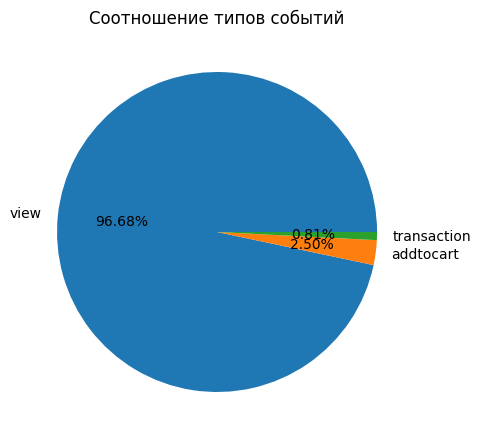

In [10]:
# Посмотрим на соотношение типов событий
show_pie(events_data, "event", "Соотношение типов событий")

Здесь:
- `view` - просмотр
- `addtocart` - добавление в корзину
- `transaction` - транзакция (покупка)

Как видим, транзакций сравнительно немного.

### Транзакции (`transactionid`)

Посмотрим, всегда ли событие  `transaction` в поле `event` соответствует факту проведения транзакции.

In [11]:
# Возьмем только записи с событием транзакции
mask_event_transaction = (events_data["event"] == "transaction")
events_data[mask_event_transaction].head()

,visitorid,event,itemid,transactionid,event_datetime
429,869008,transaction,40685,9765.0,2015-05-03 03:27:21.391
591,345781,transaction,438400,1016.0,2015-05-03 03:35:01.772
1057,586756,transaction,440917,10942.0,2015-05-03 04:01:47.591
1157,435495,transaction,175893,6173.0,2015-05-03 04:07:38.961
1522,266417,transaction,445106,12546.0,2015-05-03 04:31:14.903


Видим, что поле `transactionid` не пустое.

Проверим, есть ли пропуски в поле `transactionid`, при событии `event == transaction`.

In [12]:
mask_null_transaction = events_data["transactionid"].isna()

events_data[mask_event_transaction & mask_null_transaction]

,visitorid,event,itemid,transactionid,event_datetime


Как видим, пропусков нет.

Посмотрим, есть ли заполненный id транзакции при других типах событий.

In [13]:
events_data[~mask_event_transaction & ~mask_null_transaction]

,visitorid,event,itemid,transactionid,event_datetime


Таким образом, при событии `event == transaction` поле `transactionid` всегда заполнено.

In [14]:
print(f"Количество уникальных транзакций: {events_data['transactionid'].nunique()}")

Количество уникальных транзакций: 17672


In [15]:
print(f"Количество записей с транзакциями: {len(events_data[mask_event_transaction])}")

Количество записей с транзакциями: 22457


Таким образом, есть транзакции, на которые приходится несколько покупок.\
Посмотрим на распределение количества покупок по транзакциям.

In [16]:
transactions_volume = events_data\
    .groupby("transactionid")\
    ["itemid"].count()\
    .reset_index()\
    .rename(columns={"itemid": "items_count"})\
    .sort_values("items_count", ascending=False)

transactions_volume

,transactionid,items_count
7063,7063.0,31
765,765.0,28
8351,8351.0,27
2753,2753.0,23
6993,6993.0,21
...,...,...
6418,6418.0,1
6419,6419.0,1
6420,6420.0,1
6421,6421.0,1


In [17]:
transactions_volume["items_count"].describe()

count    17672.000000
mean         1.270767
std          0.974793
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         31.000000
Name: items_count, dtype: float64

Видим, что максимальное количество товаров в одной транзакции 31.\
Но в большинстве случаев пользователи покупали по 1-му товару.

### Пользователи (`visitorid`)

In [18]:
print(f"Количество уникальных пользователей: {events_data['visitorid'].nunique()}")

Количество уникальных пользователей: 1407580


Посмотрим, со сколькими товарами взаимодействовал каждый пользователь.

In [19]:
visitor_items_volume = events_data.pivot_table(
    index="visitorid",
    values="itemid",
    aggfunc=["count", "nunique"]
).sort_values(by=[("count", "itemid"), ("nunique", "itemid")], ascending=False)

visitor_items_volume

,count,nunique
,itemid,itemid
visitorid,,
1150086,7757,3814
530559,4328,2209
152963,3024,1622
895999,2474,1641
163561,2410,1314
...,...,...
1407575,1,1
1407576,1,1


In [20]:
visitor_items_volume.describe()

,count,nunique
,itemid,itemid
count,1.407580e+06,1.407580e+06
mean,1.957715e+00,1.524019e+00
std,1.257981e+01,7.143724e+00
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,2.000000e+00,1.000000e+00
max,7.757000e+03,3.814000e+03


Видим, что есть пользователи, которые взаимодействовали с тысячами товаров.\
Но большинство с 1-2 товарами.

Посмотрим, как распределяются транзакции по пользователям.

In [21]:
visitor_transactions_volume = events_data[mask_event_transaction].pivot_table(
    index="visitorid",
    values="itemid",
    aggfunc=["count", "nunique"]
).sort_values(by=[("count", "itemid"), ("nunique", "itemid")], ascending=False)

visitor_transactions_volume

,count,nunique
,itemid,itemid
visitorid,,
1150086,559,532
152963,349,319
530559,286,259
684514,189,184
861299,188,183
...,...,...
1406787,1,1
1406981,1,1


In [22]:
visitor_transactions_volume.describe()

,count,nunique
,itemid,itemid
count,11719.000000,11719.000000
mean,1.916290,1.815001
std,8.850529,8.347305
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,559.000000,532.000000


Есть пользователи, которые купили по несколько сотен товаров. \
Но большинство из купивших брали по 1-2 товара.

### Товары (`itemid`)

In [23]:
print(f"Количество уникальных товаров: {events_data['itemid'].nunique()}")

Количество уникальных товаров: 235061


Посмотрим, какие товары чаще покупают.

In [24]:
item_transactions_volume = events_data.pivot_table(
    index="itemid",
    values="transactionid",
    aggfunc="count"
) \
.rename(columns={"transactionid": "transactions_count"}) \
.sort_values("transactions_count", ascending=False)

item_transactions_volume

,transactions_count
itemid,
461686,133
119736,97
213834,92
312728,46
7943,46
...,...
159357,0
159359,0
159362,0


In [25]:
item_transactions_volume.describe()

,transactions_count
count,235061.000000
mean,0.095537
std,0.738321
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,133.000000


Наибольшее количество покупок для одного товара 133.\
Но большинство товаров не покупают.

### Время события (`event_datetime`)

In [26]:
min_date = str(events_data['event_datetime'].min().date())
max_date = str(events_data['event_datetime'].max().date())

print(f"Данные представлены за период с {min_date} по {max_date}.")

Данные представлены за период с 2015-05-03 по 2015-09-18.


In [27]:
# Добавим в таблицу признаки даты и времени
events_data = add_datetime_features(events_data)

events_data.head()

,visitorid,event,itemid,transactionid,event_datetime,date,year,month,day,day_of_week,hour,minute
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,2015,5,3,6,3,0
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,2015,5,3,6,3,0
2,652699,view,252860,NaN,2015-05-03 03:00:13.048,2015-05-03,2015,5,3,6,3,0
3,1125936,view,33661,NaN,2015-05-03 03:00:24.154,2015-05-03,2015,5,3,6,3,0
4,693516,view,297662,NaN,2015-05-03 03:00:26.228,2015-05-03,2015,5,3,6,3,0


Посмотрим, какое количество продаж было каждый день.

In [28]:
# Флаг наличия транзакции.
# Ниже будем суммировать это значение за каждый день.
events_data["is_transaction"] = events_data["event"] == "transaction"

transactions_time_series = events_data.pivot_table(
    index="date",
    values="is_transaction",
    aggfunc="sum",
).rename(columns={"is_transaction": "transactions_count"})

transactions_time_series

,transactions_count
date,
2015-05-03,83
2015-05-04,154
2015-05-05,225
2015-05-06,258
2015-05-07,217
...,...
2015-09-14,154
2015-09-15,158
2015-09-16,137


In [29]:
transactions_time_series.describe()

,transactions_count
count,139.000000
mean,161.561151
std,58.246368
min,15.000000
25%,112.500000
50%,162.000000
75%,207.500000
max,276.000000


Отобразим временной ряд на графике.

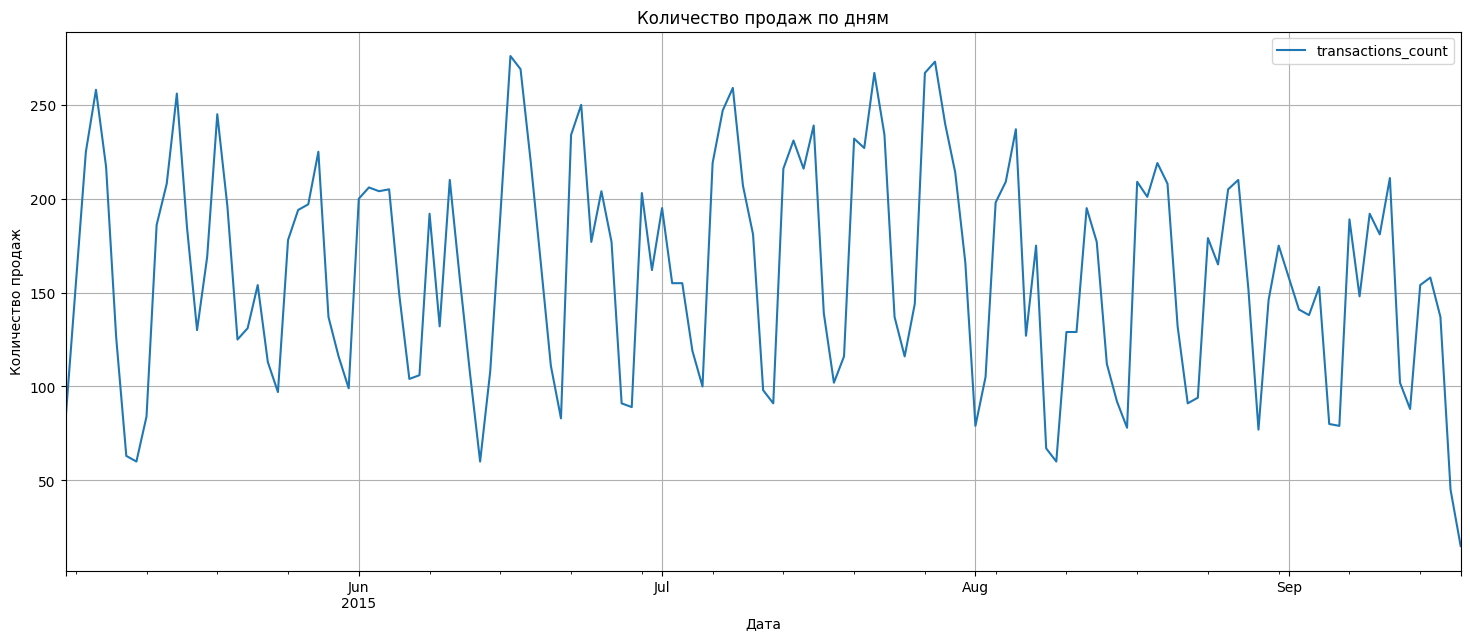

In [30]:
transactions_time_series.plot(
    figsize=(18, 7),    
    title="Количество продаж по дням",
    xlabel="Дата",
    ylabel="Количество продаж",
    grid=True,
);

На первый взгляд можно сказать, что явного тренда не наблюдается.\
Возможно, есть недельная сезонность, но нужно посмотреть график поближе.

Возьмем данные за месяц.

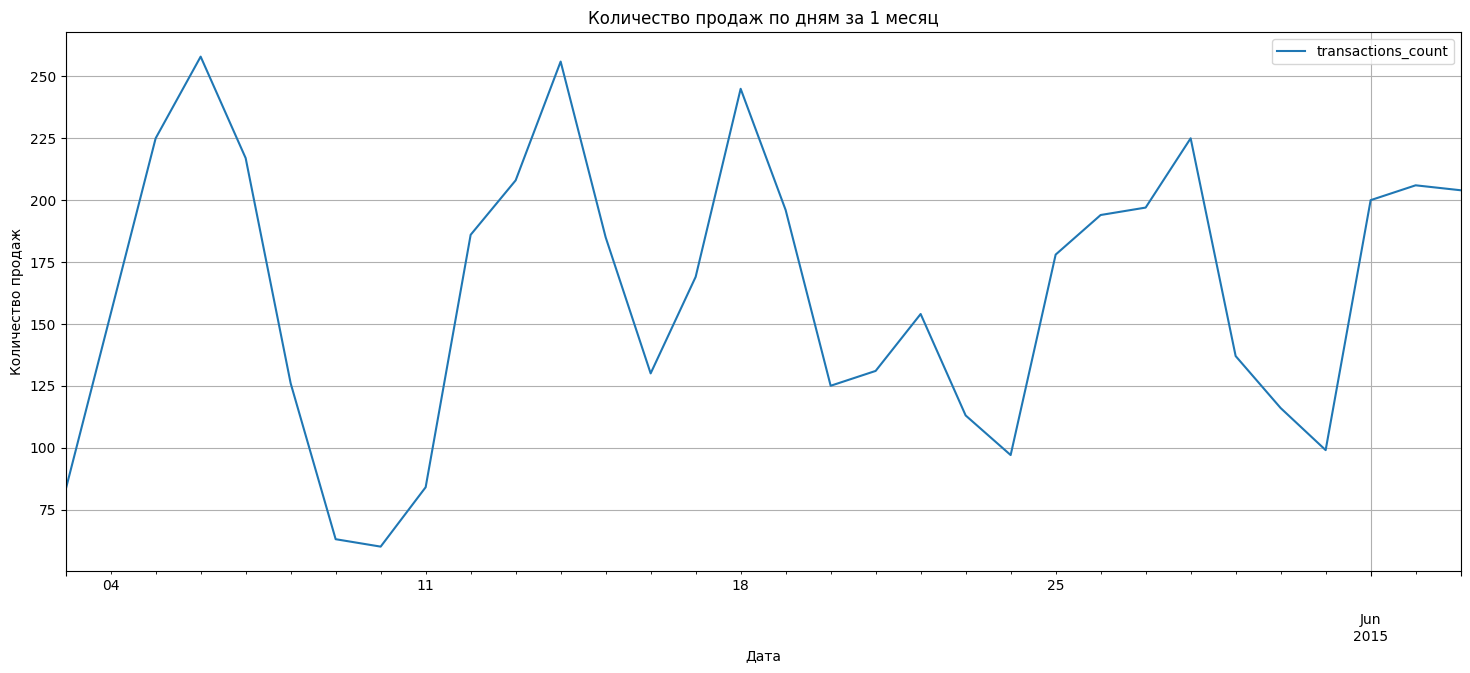

In [31]:
mask_month = transactions_time_series.index <= "2015-06-03"

transactions_time_series[mask_month].plot(
    figsize=(18, 7),    
    title="Количество продаж по дням за 1 месяц",
    xlabel="Дата",
    ylabel="Количество продаж",
    grid=True,
);

На недельную сезонность это не похоже.\
На первый взгляд можно сказать, что явных закономерностей в этом ряде не наблюдается.

Далее посмотрим, как действия пользователей распределяется по месяцам, дням и времени дня.

#### Распределение действий пользователей по месяцам

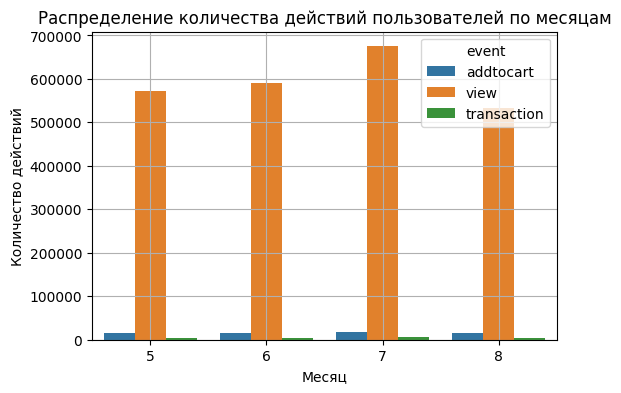

In [32]:
# Исключим из данных сентябрь, т.к. у нас данные только до 18 числа
mask_exclude_september = events_data["month"] < 9

show_countplot(
    data=events_data[mask_exclude_september],
    feature_name="month",
    title="Распределение количества действий пользователей по месяцам",
    xlabel="Месяц",
    ylabel="Количество действий",
    hue_feature_name="event",
)

Соотношение действий просмотр/добавление в корзину/покупка для каждого месяца\
примерно такое же , как на всем датасете.\
Чтобы увидеть различия по продажам, построим график для них отдельно.

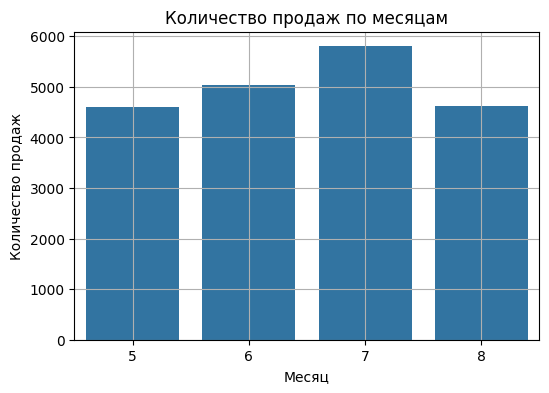

In [33]:
show_countplot(
    data=events_data[mask_exclude_september & mask_event_transaction],
    feature_name="month",
    title="Количество продаж по месяцам",
    xlabel="Месяц",
    ylabel="Количество продаж",
)

Наибольшее количество продаж просмотров (и продаж) было в июле. \
И общее количество действий распределено по месяцам примерно одинаково.

#### Распределение действий пользователей по числам месяца

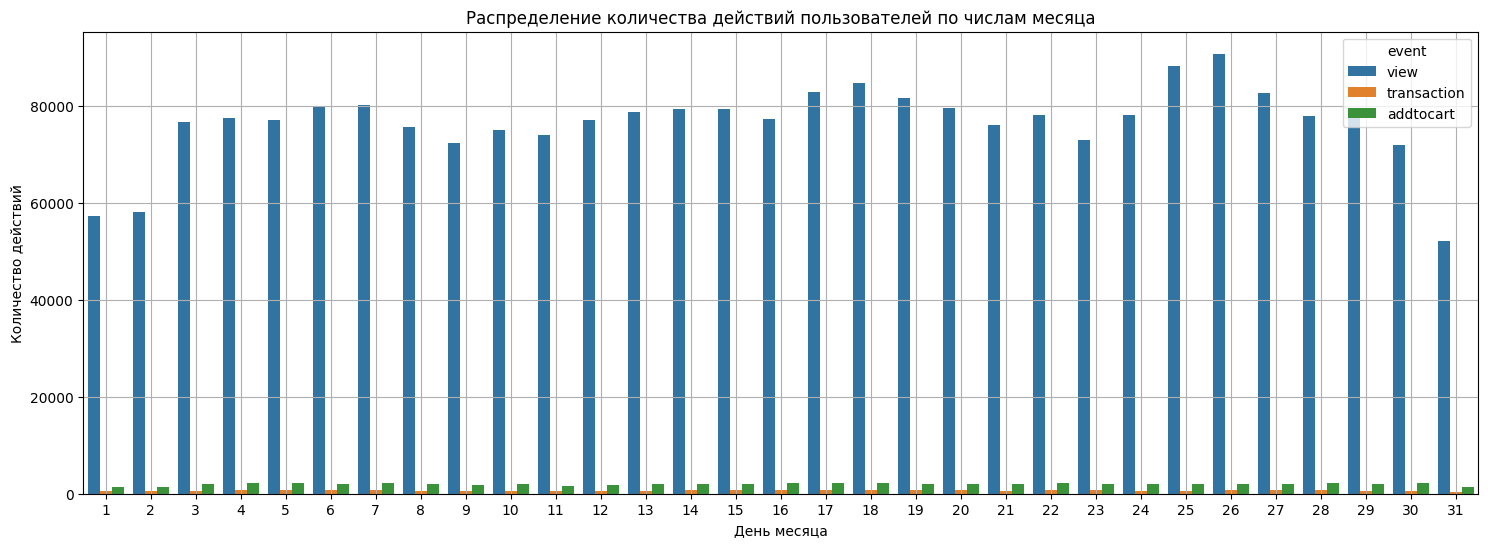

In [34]:
show_countplot(
    # Так же исключим сентябрь, т.к. за него не полные данные
    data=events_data[mask_exclude_september],
    feature_name="day",
    title="Распределение количества действий пользователей по числам месяца",
    xlabel="День месяца",
    ylabel="Количество действий",
    figsize=(18, 6),
    hue_feature_name="event",
)

Здесь также соотношение действий просмотр/добавление в корзину/покупка по дням\
примерно такое же, как на всем датасете.\
31 число есть не в каждом месяце, поэтому в эту дату просмотров посчиталось меньше.\
Также можно заметить, что 1 и 2 числа просмотров меньше.\
Чтобы увидеть изменения по покупкам, построим по ним график отдельно.

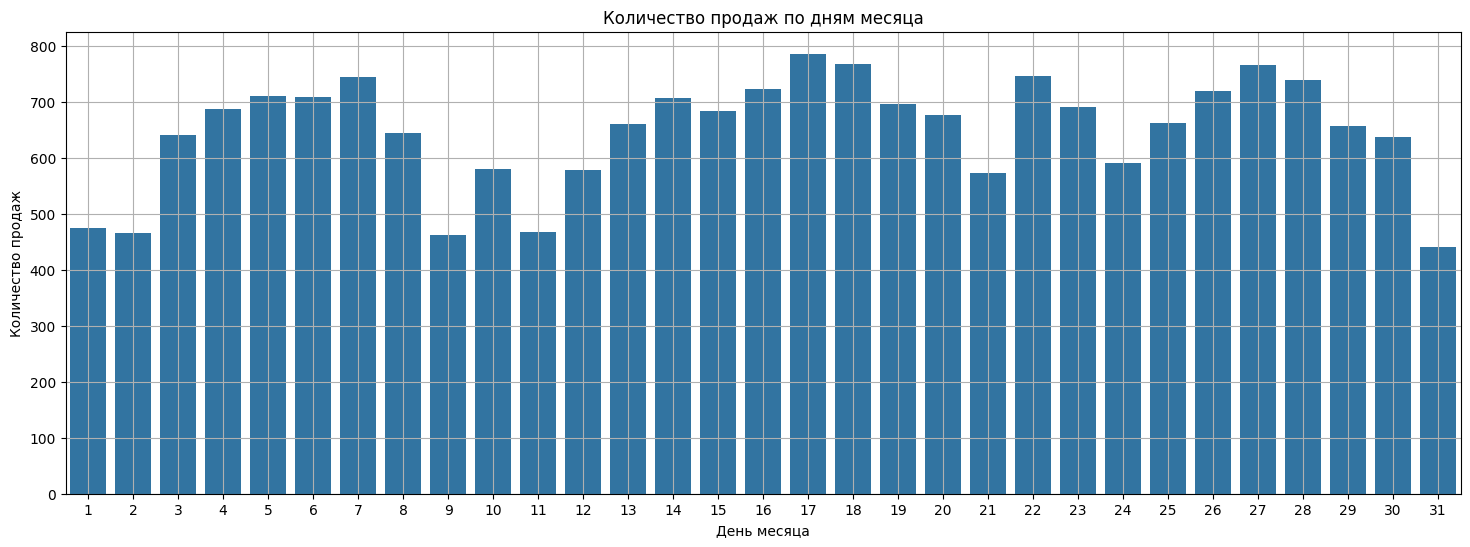

In [35]:
show_countplot(
    data=events_data[mask_exclude_september & mask_event_transaction],
    feature_name="day",
    title="Количество продаж по дням месяца",
    xlabel="День месяца",
    ylabel="Количество продаж",
    figsize=(18, 6),
)

Здесь можно увидеть некоторую "волнообразность".\
Меньше покупок приходится на числа 1-2, 9-11, 21, 24, 31.\
С чем это связано пока сложно сказать.

#### Распределение действий пользователей по дням недели

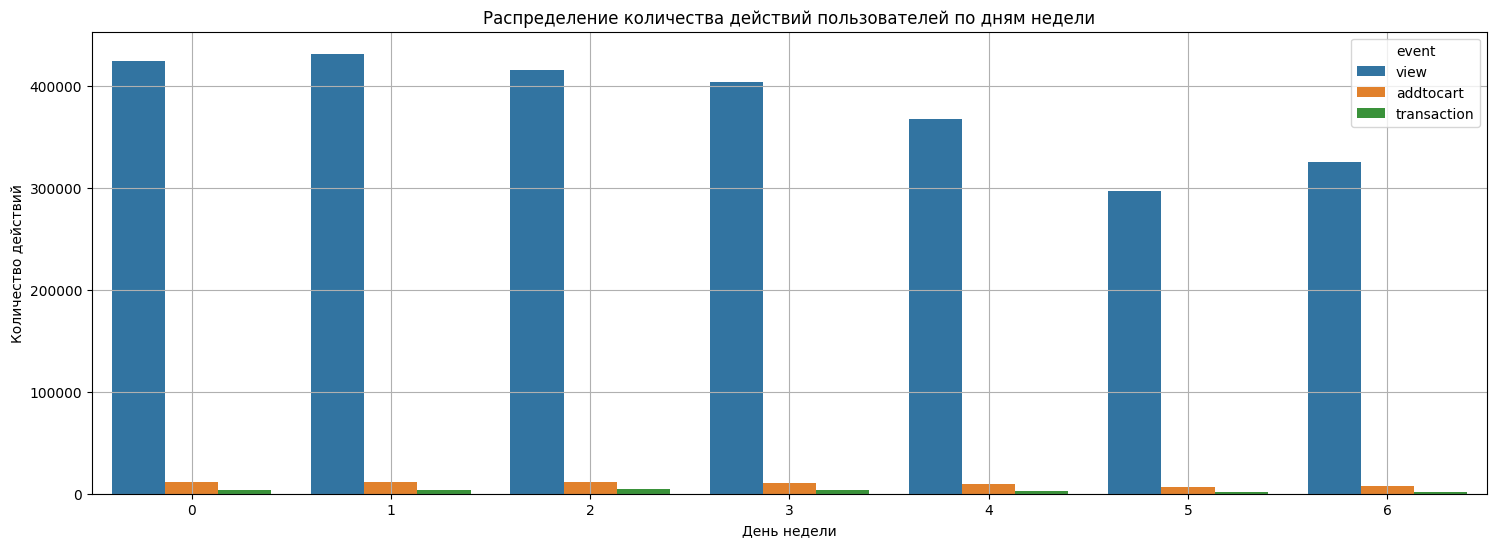

In [36]:
show_countplot(
    data=events_data,
    feature_name="day_of_week",
    title="Распределение количества действий пользователей по дням недели",
    xlabel="День недели",
    ylabel="Количество действий",
    figsize=(18, 6),
    hue_feature_name="event",
)

Здесь обозначения дней недели:
- 0 - понедельник
- 6 - воскресенье

Наибольшая активность в начале недели. И она спадает к выходным.\
Посмотрим отдельно график по покупкам.

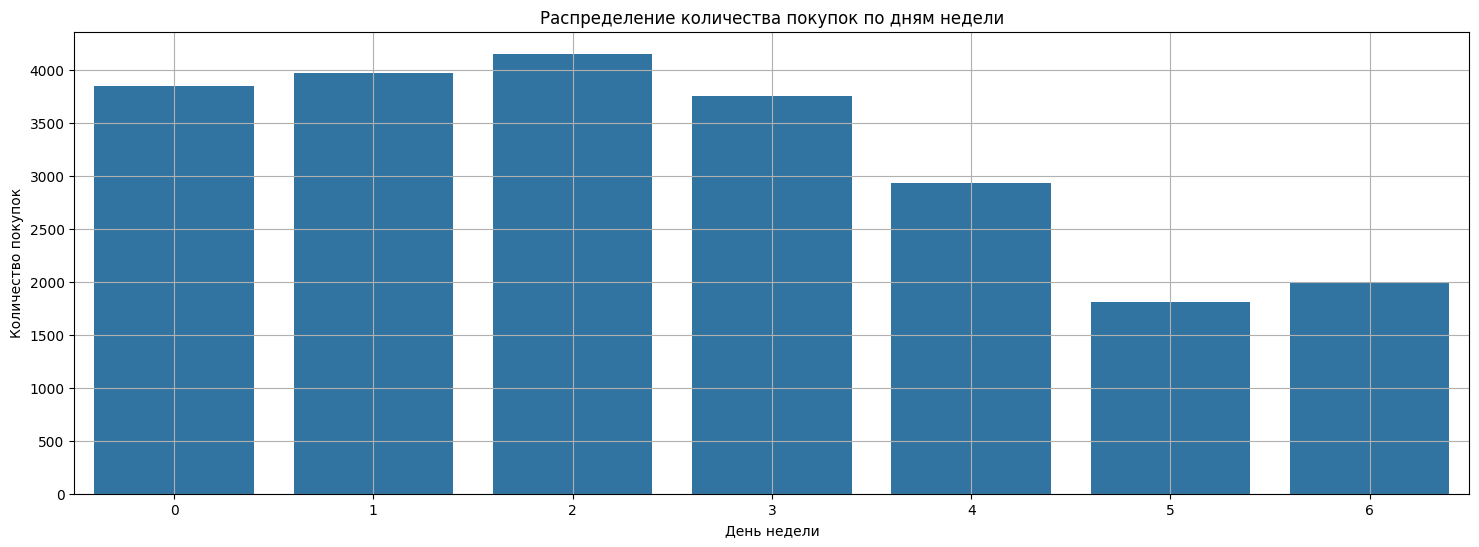

In [37]:
show_countplot(
    data=events_data[mask_event_transaction],
    feature_name="day_of_week",
    title="Распределение количества покупок по дням недели",
    xlabel="День недели",
    ylabel="Количество покупок",
    figsize=(18, 6),
)

Видно, что количество покупок по дням недели примерно пропорционально количеству просмотров.\
И так же количество больше в начале недели и спадает к выходным.

#### Распределение действий пользователей по часам

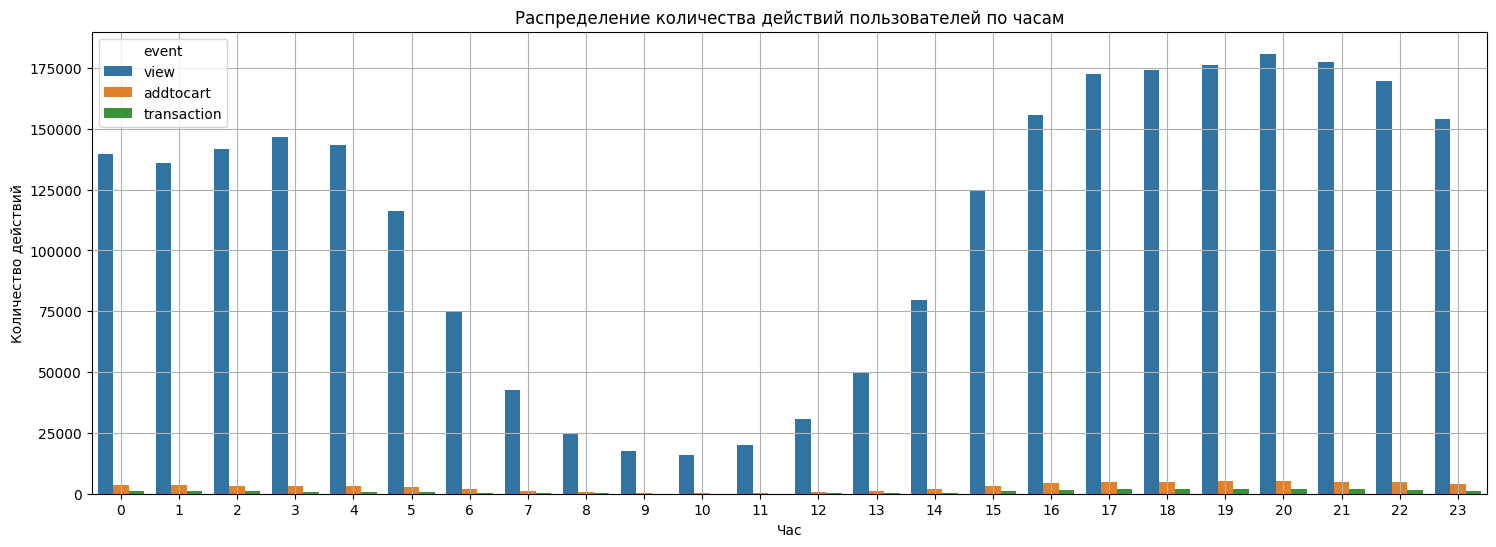

In [38]:
show_countplot(
    data=events_data,
    feature_name="hour",
    title="Распределение количества действий пользователей по часам",
    xlabel="Час",
    ylabel="Количество действий",
    figsize=(18, 6),
    hue_feature_name="event",
)

С 6  до 14 часов активность пользователей более низкая.\
Посмотрим отдельно, как по времени дня распределяются транзакции.

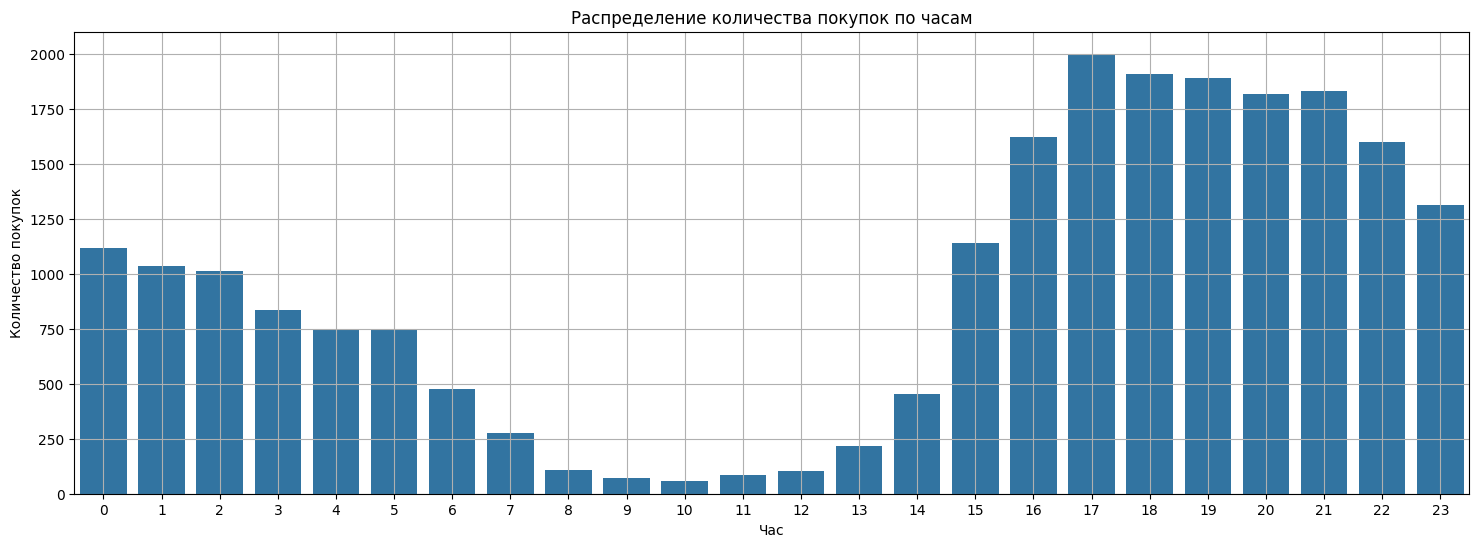

In [39]:
show_countplot(
    data=events_data[mask_event_transaction],
    feature_name="hour",
    title="Распределение количества покупок по часам",
    xlabel="Час",
    ylabel="Количество покупок",
    figsize=(18, 6),
)

Видно ту же тенденцию, что и для просмотров.\
С 6 до 14 часов активность пользователей ниже.

Добавим признак `time_of_day` с временем дня.

In [40]:
events_data["time_of_day"] = events_data["hour"].apply(get_time_of_day)

Исследуем новый признак.

#### Распределение количества покупок по времени дня

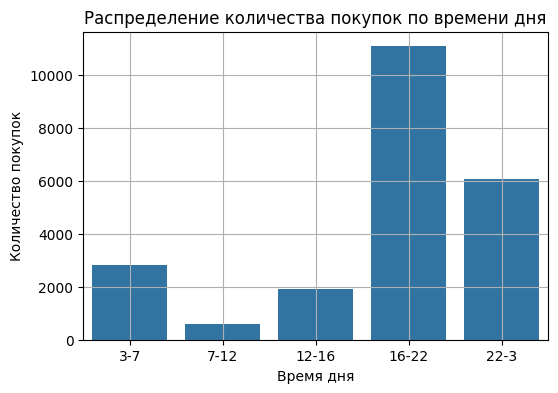

In [41]:
show_countplot(
    data=events_data[mask_event_transaction],
    feature_name="time_of_day",
    title="Распределение количества покупок по времени дня",
    xlabel="Время дня",
    ylabel="Количество покупок",
)

Разница в количестве покупок для этих промежутков явно наблюдается.

#### Распределение транзакций по дням недели и часам

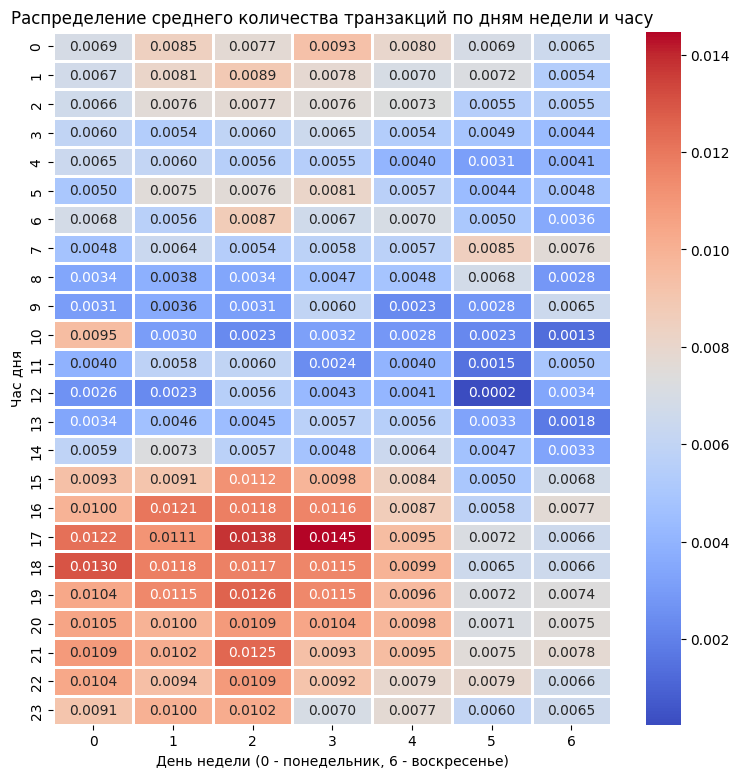

In [42]:
transactions_in_days_and_hours = events_data.pivot_table(
    index="hour",
    columns="day_of_week",
    values="is_transaction",
    aggfunc="mean"
)

min_transactions = transactions_in_days_and_hours.min().min()
max_transactions = transactions_in_days_and_hours.max().max()

# Фигура и координатная плоскость
fig, axes = plt.subplots(figsize=(9, 9))

# Параметры тепловой карты
sns.heatmap(
    transactions_in_days_and_hours, 
    annot=True, 
    vmin=min_transactions, 
    vmax=max_transactions, 
    center=(min_transactions + max_transactions) / 2, 
    linewidths=.9, 
    ax=axes, 
    fmt=".4f", 
    cmap="coolwarm",
)
plt.title("Распределение среднего количества транзакций по дням недели и часу")
plt.xlabel("День недели (0 - понедельник, 6 - воскресенье)")
plt.ylabel("Час дня")

# Выведем график
plt.show()

В среднем наибольшее количество покупок приходилось на первую половину недели с 15 до 23 часов.

### Популярность товаров в зависимости от времени

#### Популярность товаров по месяцам

Посмотрим, меняются ли популярные товары в зависимости от месяца или они постоянны.

In [43]:
# Возьмем по 5 самых популярных товаров в каждом месяце
month_popular_items = events_data[mask_event_transaction] \
    .groupby(by=["month"]) \
    ["itemid"].value_counts().reset_index() \
    .groupby("month").head(5)

month_popular_items

,month,itemid,count
0,5,369447,31
1,5,7943,17
2,5,318333,17
3,5,379520,14
4,5,51354,11
3376,6,119736,25
3377,6,382885,18
3378,6,461686,17
3379,6,48030,16
3380,6,312728,14


In [44]:
# Переведем id товара в строковый вид, чтобы на графике он отображался как
# категориальный признак
month_popular_items["itemid"] = month_popular_items["itemid"].astype(str)

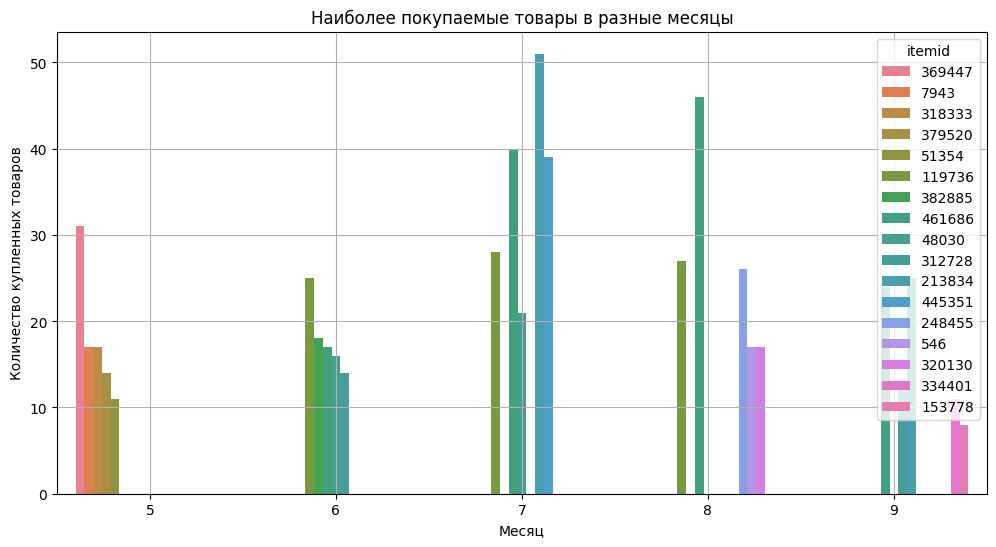

In [45]:
# Отобразим данные на графике
fig = plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=month_popular_items, 
    x=month_popular_items["month"], 
    y=month_popular_items["count"],
    hue="itemid",
)
plt.title("Наиболее покупаемые товары в разные месяцы")
ax.set(xlabel="Месяц", ylabel="Количество купленных товаров")
ax.grid(True)
plt.show()

Видим, что некоторые товары повторяются, но картина каждый месяц разная.

#### Популярность товаров по времени дня

In [46]:
# Возьмем по 5 самых популярных товаров в каждое время дня
time_popular_items = events_data[mask_event_transaction] \
    .groupby(by=["time_of_day"]) \
    ["itemid"].value_counts().reset_index() \
    .groupby("time_of_day").head(5)

time_popular_items

,time_of_day,itemid,count
0,12-16,213834,8
1,12-16,461686,8
2,12-16,441852,6
3,12-16,12217,5
4,12-16,256146,5
1611,16-22,119736,64
1612,16-22,461686,52
1613,16-22,213834,34
1614,16-22,7943,24
1615,16-22,445351,23


In [47]:
# Переведем id товара в строковый вид, чтобы на графике он отображался как
# категориальный признак
time_popular_items["itemid"] = time_popular_items["itemid"].astype(str)

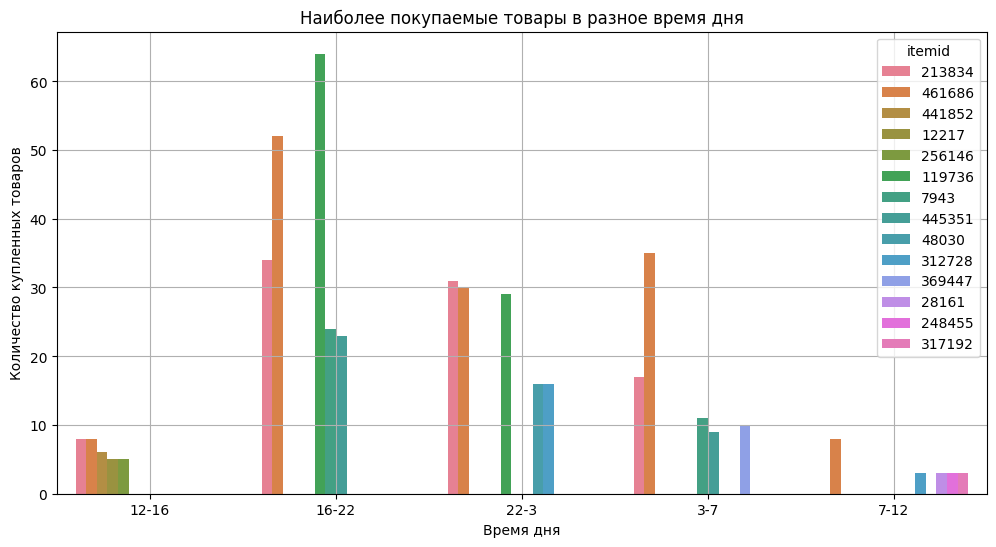

In [48]:
# Отобразим данные на графике
fig = plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=time_popular_items, 
    x=time_popular_items["time_of_day"], 
    y=time_popular_items["count"],
    hue="itemid",
)
plt.title("Наиболее покупаемые товары в разное время дня")
ax.set(xlabel="Время дня", ylabel="Количество купленных товаров")
ax.grid(True)
plt.show()

Видно, что в любое время дня одним из популярных товаров остается 461686.\
119736 наиболее популярен с 16 до 22.

### Постоянство состава посетителей сайта по месяцам

Посмотрим, насколько постоянен контингент посетителей сайта.\
Много ли постоянных, и как состав меняется от месяца к месяцу.

In [49]:
# Первый месяц, который рассматриваем
start_month = events_data["month"].min()
# Последний месяц, который рассматриваем
end_month = events_data["month"].max()

# Словарь с уникальными идентификаторами посетителей в каждом месяце
userids_by_months = dict()

# Заполним словарь userids_by_months
for month in range(start_month, end_month+1):
    mask_month = events_data["month"] == month
    
    userids_by_months[month] = set(events_data[mask_month]["visitorid"].unique())

In [50]:
# Сюда будем собирать идентификаторы посетителей, которые заходили на сайт в каждом месяце
userids_in_all_months = userids_by_months[start_month]

# Словарь с количеством посетителей, 
# которые заходили на сайт и в данном месяце и в прошлом месяце
user_counts_in_prev_and_next_months = dict()

for month in range(start_month+1, end_month+1):
    # Посетители в прошлом месяце
    userids_in_prev_month = userids_by_months[month-1]
    # Посетители в текущем месяце
    userids_in_current_month = userids_by_months[month]
    
    # Посетители, которые есть и в прошлом и в текущем месяце
    userids_in_both_months = userids_in_prev_month & userids_in_current_month

    # Запомним количество общих посетителей в прошлом и текущем месяце
    user_counts_in_prev_and_next_months[f"{month-1}-{month}"] = len(userids_in_both_months)
    
    # Выделим множество посетителей, которые повторяются в каждом месяце
    userids_in_all_months = userids_in_all_months & userids_in_current_month
    

In [51]:
print("Количество посетителей, которые заходили на сайт в прошлом и следующем месяцах:")
print(user_counts_in_prev_and_next_months)

Количество посетителей, которые заходили на сайт в прошлом и следующем месяцах:
{'5-6': 14643, '6-7': 15301, '7-8': 14135, '8-9': 9536}


Для понимания масштаба переведем эти цифры в проценты.

In [52]:
# Словарь с процентным соотношением посетителей, которые перетекли из прошлого месяца в текущий
users_percent_from_prev_months = dict()

for month in range(start_month+1, end_month+1):
    users_percent_from_prev_months[month] = round(
        user_counts_in_prev_and_next_months[f"{month-1}-{month}"] /
        len(userids_by_months[month]) * 100,
        2
    )

print("Процент посетителей, которые были на сайте в прошлом месяце и зашли в текущем:")
print(users_percent_from_prev_months)

Процент посетителей, которые были на сайте в прошлом месяце и зашли в текущем:
{6: 4.67, 7: 4.06, 8: 4.54, 9: 5.49}


> В каждом следующем месяце на сайт заходит только 4-5% посетителей из прошлого месяца.

In [53]:
print(
    "Количество постоянных посетителей, которые заходили на сайт в каждом месяце:",
    len(userids_in_all_months)
)
print(
    "Процент постоянных посетителей, которые заходили на сайт в каждом месяце:",
    round(len(userids_in_all_months) / len(events_data["visitorid"].unique()) * 100, 4)
)

Количество постоянных посетителей, которые заходили на сайт в каждом месяце: 354
Процент постоянных посетителей, которые заходили на сайт в каждом месяце: 0.0251


> То есть, довольно небольшой контингент постоянных посетителей.\
Меньше 1% от общего числа.

### Постоянство состава покупаемых товаров по месяцам

Теперь посмотрим аналогичную информацию по товарам.

In [54]:
# Словарь с уникальными идентификаторами товаров, покупаемых в каждом месяце
itemids_by_months = dict()

# Маска для фильтра транзакций
mask_transaction = (events_data["is_transaction"] == True)

# Заполним словарь itemids_by_months
for month in range(start_month, end_month+1):
    mask_month = (events_data["month"] == month)
    
    itemids_by_months[month] = set(events_data[mask_month & mask_transaction]["itemid"].unique())

In [55]:
# Сюда будем собирать идентификаторы товаров, которые покупали в каждом месяце
itemids_in_all_months = itemids_by_months[start_month]

# Словарь с количеством товаров, 
# которые покупали и в данном месяце и в прошлом месяце
item_counts_in_prev_and_next_months = dict()

for month in range(start_month+1, end_month+1):
    # Купленные товары в прошлом месяце
    itemids_in_prev_month = itemids_by_months[month-1]
    # Купленные товары в текущем месяце
    itemids_in_current_month = itemids_by_months[month]
    
    # Товары, которые есть и в прошлом и в текущем месяце
    itemids_in_both_months = itemids_in_prev_month & itemids_in_current_month

    # Запомним количество общих товаров в прошлом и текущем месяце
    item_counts_in_prev_and_next_months[f"{month-1}-{month}"] = len(itemids_in_both_months)
    
    # Выделим множество товаров, которые повторяются в каждом месяце
    itemids_in_all_months = itemids_in_all_months & itemids_in_current_month
    

In [56]:
print("Количество товаров, которые покупали в прошлом и следующем месяцах:")
print(item_counts_in_prev_and_next_months)

Количество товаров, которые покупали в прошлом и следующем месяцах:
{'5-6': 734, '6-7': 859, '7-8': 821, '8-9': 457}


Для понимания масштаба переведем эти цифры в проценты.

In [57]:
# Словарь с процентным соотношением товаров, которые перетекли из прошлого месяца в текущий
items_percent_from_prev_months = dict()

for month in range(start_month+1, end_month+1):
    items_percent_from_prev_months[month] = round(
        item_counts_in_prev_and_next_months[f"{month-1}-{month}"] /
        len(itemids_by_months[month]) * 100,
        2
    )

print("Процент товаров, которые купили на сайте и в прошлом месяце и в текущем:")
print(items_percent_from_prev_months)

Процент товаров, которые купили на сайте и в прошлом месяце и в текущем:
{6: 20.45, 7: 21.35, 8: 24.7, 9: 25.07}


> Надо заметить, что постоянство у покупаемых товаров больше, чем у пользователей.\
> В каждом следующем месяце покупается 20-25% товаров из прошлого месяца.

In [ ]:
print(
    "Количество постоянных товаров, которые покупали в каждом месяце:",
    len(itemids_in_all_months)
)
print(
    "Процент постоянных товаров, которые покупали в каждом месяце:",
    round(len(itemids_in_all_months) / len(events_data[mask_transaction]["itemid"].unique()) * 100, 4),
    "%"
)

Количество постоянных товаров, которые покупали в каждом месяце: 42
Процент постоянных товаров, которые покупали в каждом месяце: 0.3493


## Дерево категорий (`category_data`)

In [59]:
# Посмотрим основную информацию о таблице
display_common_data_info(category_data)

**Первые строки таблицы:**

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


**Размерность таблицы:** (1669, 2)

**Информация о столбцах:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


None

**Пропуски:**

categoryid     0
parentid      25
dtype: int64

**Количество дубликатов:** 0

Пропуски в столбце `parentid` видимо, у тех категорий, которые являются родительскими для всех.

In [60]:
print(f"Количество уникальных категорий: {category_data['categoryid'].nunique()}")

Количество уникальных категорий: 1669


Сформируем признак в виде цепочки категорий (от корневой до текущей).

In [61]:
# Создадим словарь из таблицы с категориями, 
# т.к. по нему будет быстрее происходить поиск, чем по таблице
catid_to_parentid = category_data.set_index("categoryid")["parentid"].to_dict()

In [62]:
# Сформируем признак в виде цепочки категорий (от корневой до текущей)
category_data["levels_path"] = category_data["categoryid"].apply(
    lambda categoryid: get_categories_levels_path(catid_to_parentid, categoryid)
)

# Добавим признак с количеством уровней категорий в цепочке
category_data["levels_count"] = category_data["levels_path"].apply(get_categories_levels_count)

# Извлечем также корневую категорию
category_data["root_categoryid"] = category_data["levels_path"].apply(get_root_category)

In [63]:
# Посмотрим на результат
category_data.head()

,categoryid,parentid,levels_path,levels_count,root_categoryid
0,1016,213.0,"[1532, 1299, 213, 1016]",4,1532
1,809,169.0,"[395, 1257, 169, 809]",4,395
2,570,9.0,"[653, 351, 9, 570]",4,653
3,1691,885.0,"[1579, 885, 1691]",3,1579
4,536,1691.0,"[1579, 885, 1691, 536]",4,1579


In [64]:
print(f"Максимальная глубина каталога: {category_data['levels_count'].max()}")

print(f"Минимальная глубина каталога: {category_data['levels_count'].min()}")

print(f"Количество корневых категорий: {category_data['root_categoryid'].nunique()}")

Максимальная глубина каталога: 6
Минимальная глубина каталога: 1
Количество корневых категорий: 25


Посмотрим на количество подкатегрий в каждой корневой категории.

In [65]:
category_data.pivot_table(
    index="root_categoryid",
    values="categoryid",
    aggfunc="count"
) \
.rename(columns={"categoryid": "categories_count"}) \
.sort_values("categories_count", ascending=False)

,categories_count
root_categoryid,
140,290
1600,187
653,154
1579,135
1532,130
395,120
1482,101
250,97
1224,70


Максимальное количество вложенных категорий (включая корневую) 290 штук.

## Товары (`items_data`)

In [66]:
# Посмотрим основную информацию о таблице
display_common_data_info(items_data)

**Первые строки таблицы:**

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


**Размерность таблицы:** (20275902, 4)

**Информация о столбцах:**

<class 'pandas.core.frame.DataFrame'>
Index: 20275902 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 773.5+ MB


None

**Пропуски:**

timestamp    0
itemid       0
property     0
value        0
dtype: int64

**Количество дубликатов:** 0

In [67]:
# Переведем признак timestamp в формат с отображением даты и времени
items_data = convert_timespamp_to_datetime(items_data)

items_data.head()

,itemid,property,value,event_datetime
0,317951,790,n32880.000,2015-05-10 03:00:00
1,422842,480,1133979,2015-05-10 03:00:00
2,310185,776,103591,2015-05-10 03:00:00
3,110973,112,679677,2015-05-10 03:00:00
4,179597,available,0,2015-05-10 03:00:00


Данная таблица, видимо, представляет из себя историю изменения свойств товаров.\
И каждая последующая запись либо переписывает, либо дополняет информацию о предыдущих записях для товара.

Далее подробнее исследуем каждый признак.

### Товары (`itemid`)

In [68]:
# Вынесем количество уникальных товаров в переменную, она нам далее пригодится
unique_items_count = items_data['itemid'].nunique()

print(f"Количество уникальных товаров: {unique_items_count}")

Количество уникальных товаров: 417053


Посмотрим, какое количество записей и уникальных свойств приходится на каждый товар.

In [69]:
items_properties_volume = items_data.pivot_table(
    index="itemid",
    values="property",
    aggfunc=["count", "nunique"],
).sort_values([("count", "property"), ("nunique", "property")])

items_properties_volume

,count,nunique
,property,property
itemid,,
207227,12,12
243157,12,12
73456,13,13
342400,14,14
19664,15,15
...,...,...
339536,444,53
150800,459,51


In [70]:
items_properties_volume.describe()

,count,nunique
,property,property
count,417053.000000,417053.000000
mean,48.617087,28.782466
std,27.385722,7.409326
min,12.000000,12.000000
25%,28.000000,24.000000
50%,42.000000,27.000000
75%,60.000000,31.000000
max,468.000000,59.000000


Таким образом, каждый товар изменялся минимум 12 раз. \
И для каждого товара установлено минимум 12 уникальных свойств.

### Свойства (`property`) и их значения (`value`)

In [71]:
# Посмотрим на конец таблицы
items_data.tail(3)

,itemid,property,value,event_datetime
20275899,161357,888,12762 16970 145048 237874 1229126 784581 1297729 n36.000 350726 30603 832471,2015-09-13 03:00:00
20275900,267142,available,0,2015-09-13 03:00:00
20275901,275768,888,888666 n10800.000 746840 1318567,2015-09-13 03:00:00


Можно заметить, что поле `value` иногда включает несколько значений через пробел.\
Добавим признаки, которые будут содержать общее количество значений \
и количество уникальных значений \
в строке  `value`.

In [72]:
items_data["values_count"] = items_data["value"].apply(get_values_count)
items_data["unique_values_count"] = items_data["value"].apply(get_unique_values_count)

In [73]:
# Посмотрим на распределение созданных свойств
items_data[["values_count", "unique_values_count"]].describe()

,values_count,unique_values_count
count,2.027590e+07,2.027590e+07
mean,2.529907e+00,2.352839e+00
std,5.001385e+00,4.113254e+00
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,2.000000e+00,2.000000e+00
max,5.900000e+01,4.300000e+01


Чаще указано 1-2 значения внутри поля `value`.\
Но может быть и несколько десятков значений.

In [74]:
print(f"Количество уникальных свойств (property): {items_data['property'].nunique()}")

print(f"Количество уникальных значений свойств (value): {items_data['value'].nunique()}")

Количество уникальных свойств (property): 1104
Количество уникальных значений свойств (value): 1966868


Посмотрим, сколько уникальных значений приходится на каждое свойство.

In [75]:
property_values_volume = items_data.pivot_table(
    index="property",
    values="value",
    aggfunc="nunique"
) \
.rename(columns={"value": "unique_values_count"}) \
.sort_values("unique_values_count", ascending=False)

property_values_volume

,unique_values_count
property,
888,454723
364,420554
917,400893
283,333165
776,328837
...,...
516,1
129,1
722,1


In [64]:
property_values_volume.describe()

,unique_values_count
count,1104.000000
mean,2189.555254
std,27593.830392
min,1.000000
25%,3.000000
50%,9.000000
75%,38.250000
max,454723.000000


Разброс количества уникальных значений для свойств довольно большой.

Посмотрим на наиболее популярные свойства. То есть, свойства, которые указаны у большинства товаров.

In [76]:
property_items_volume = items_data.pivot_table(
    index="property",
    values="itemid",
    aggfunc="nunique"
) \
.rename(columns={"itemid": "unique_items_count"}) \
.sort_values("unique_items_count", ascending=False)

In [77]:
property_items_volume

,unique_items_count
property,
categoryid,417053
159,417053
790,417053
364,417053
112,417053
...,...
744,1
244,1
769,1


Количество уникальных товаров у нас `417053`.\
Тот факт, что некоторые значения `property` есть у такого количества товаров,\
говорит о том, что они есть у всех товаров.\
Посмотрим, сколько у нас свойств, которые отмечены для каждого товара.

In [78]:
# Выше количество уникальных товаров мы занесли в переменную unique_items_count
print(f"Количество уникальных товаров {unique_items_count}")

Количество уникальных товаров 417053


In [79]:
mask_common_properties = property_items_volume["unique_items_count"] == unique_items_count
property_items_volume[mask_common_properties]

,unique_items_count
property,
categoryid,417053
159,417053
790,417053
364,417053
112,417053
888,417053
764,417053
283,417053
available,417053


In [80]:
print(f"Количество свойств, которые есть у каждого товара: {len(property_items_volume[mask_common_properties])}") 

Количество свойств, которые есть у каждого товара: 9


Изучим подробнее каждое из этих свойств.

#### `property == 790`

In [81]:
display_property_info(items_data, "790")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
0,317951,790,n32880.000,2015-05-10 03:00:00,1,1
16,434987,790,n24480.000,2015-05-10 03:00:00,1,1
43,11251,790,n157680.000,2015-05-10 03:00:00,1,1
127,287098,790,n11160.000,2015-05-10 03:00:00,1,1
151,14095,790,n15360.000,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 33052

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
71,18,18
460,18,18
552,18,18
623,18,18
1322,18,18
...,...,...
466859,1,1
466862,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.000000,417053.000000
mean,4.293258,1.819869
std,6.618660,2.369999
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,18.000000,18.000000


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
2305946,71,790,n145680.000,2015-05-10 03:00:00,1,1
3049466,71,790,n145920.000,2015-05-17 03:00:00,1,1
4152874,71,790,n139440.000,2015-05-24 03:00:00,1,1
6252560,71,790,n144960.000,2015-05-31 03:00:00,1,1
9662676,71,790,n158280.000,2015-06-07 03:00:00,1,1
10195015,71,790,n142200.000,2015-06-14 03:00:00,1,1
12235700,71,790,n142080.000,2015-06-28 03:00:00,1,1
13315131,71,790,n142800.000,2015-07-05 03:00:00,1,1
14201775,71,790,n145320.000,2015-07-12 03:00:00,1,1
14597678,71,790,n143160.000,2015-07-19 03:00:00,1,1


Это свойство очень напоминает цену.\
Значение `n` в начале может обозначать, что это именно число (`numerical`), а не идентификатор.\
А часть после точки может означать дробную часть.\
Позже попробуем использовать его как численное свойство для товаров.

#### `property == 764`

In [82]:
display_property_info(items_data, "764")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
6,138592,764,1285872,2015-05-10 03:00:00,1,1
8,299944,764,1285872,2015-05-10 03:00:00,1,1
13,120326,764,1285872,2015-05-10 03:00:00,1,1
32,229112,764,1285872,2015-05-10 03:00:00,1,1
48,15120,764,1285872,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 1

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
466862,1,1
466863,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.0,417053.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
8048767,0,764,1285872,2015-05-31 03:00:00,1,1


То есть, для каждого товара это свойство указано ровно один раз.\
И оно всегда имеет одно и то же значение.\
Поэтому как признак оно нам не пригодится.

#### `property == 888`

In [83]:
display_property_info(items_data, "888")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
11,94981,888,47849 n706440.000,2015-05-10 03:00:00,2,2
70,188769,888,150169 6872 614733 1071661 413916,2015-05-10 03:00:00,5,5
85,362242,888,641688 1259019,2015-05-10 03:00:00,2,2
89,122298,888,150169 727528 700105 1312425 697645 n9432.000,2015-05-10 03:00:00,6,6
108,457682,888,1215939 n14820.000,2015-05-10 03:00:00,2,2


**Количество уникальных значений `value` свойства:** 454723

**Максимальное значение `values_count`:** 53

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
134131,18,5
464220,18,5
3071,18,4
4021,18,4
8362,18,4
...,...,...
466859,1,1
466861,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.000000,417053.000000
mean,7.194285,1.381467
std,8.107819,0.516170
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,18.000000,2.000000
max,18.000000,5.000000


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
2628006,134131,888,629801 983505,2015-05-10 03:00:00,2,2
3416666,134131,888,629801 983505,2015-05-17 03:00:00,2,2
5730297,134131,888,629801 983505,2015-05-24 03:00:00,2,2
6299063,134131,888,629801 983505,2015-05-31 03:00:00,2,2
9596046,134131,888,629801 983505,2015-06-07 03:00:00,2,2
10274723,134131,888,629801 983505,2015-06-14 03:00:00,2,2
12443349,134131,888,629801 983505,2015-06-28 03:00:00,2,2
13522934,134131,888,629801 983505,2015-07-05 03:00:00,2,2
14154505,134131,888,629801 983505 726612 706030 798443 86628,2015-07-12 03:00:00,6,6
14501390,134131,888,629801 983505 726612 706030 798443 86628,2015-07-19 03:00:00,6,6


У этого свойства может быть длинная строка `value` из нескольких десятков отдельных значений.\
Есть предположение, что в нем задано вхождение товара в какие-то фильтры\
или обобщение ранее заданных свойтсв.\
Для категориального признака оно имеет слишком много уникальных значений.\
Если пытаться векторизовать эти наборы значений с помощью `TfidfVectorizer`, например, \
то, забегая вперед, можно сказать, что опытным путем установлено, что эти значения добавят шума.\
Поэтому не будем использовать этот признак.

#### `property == 283`

In [84]:
display_property_info(items_data, "283")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
12,431201,283,628374 827388 738621 628374 372324 703408 1182824 372324 892975 n48.000 1322464 237874 914255 727274 1273256 110652 1086985 1010780 145048 834282 827388 550504 780028 85384 303286 1094068 808508 976593 210086 1297039 197566,2015-05-10 03:00:00,31,28
17,442160,283,1249027 212349 129268 726702,2015-05-10 03:00:00,4,4
25,40893,283,125018 1137617 424149 358393 566381 n3600.000,2015-05-10 03:00:00,6,6
87,343582,283,1312959 767591 435885 15301,2015-05-10 03:00:00,4,4
122,324983,283,8496 639039 n48.000 229045,2015-05-10 03:00:00,4,4


**Количество уникальных значений `value` свойства:** 333165

**Максимальное значение `values_count`:** 59

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
281441,18,5
305,18,4
4317,18,4
4693,18,4
6879,18,4
...,...,...
466862,1,1
466863,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.000000,417053.000000
mean,1.432477,1.027790
std,2.667154,0.180595
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,18.000000,5.000000


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
759050,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-05-10 03:00:00,31,26
3548365,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-05-17 03:00:00,31,26
5042409,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-05-24 03:00:00,31,26
7776812,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-05-31 03:00:00,31,26
9472436,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-06-07 03:00:00,31,26
10263527,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 876603 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 876603 1186610,2015-06-14 03:00:00,31,26
13098279,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-06-28 03:00:00,31,26
13344519,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-07-05 03:00:00,31,26
14363144,281441,283,588652 1091491 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423 1186610,2015-07-12 03:00:00,31,26
14740973,281441,283,288796 588652 768453 881782 614871 188678 1091491 881782 373943 n6000.000 207063 989224 1215254 380713 1321579 707081 242423 1071434 260172 980836 63555 484436 1075775 22060 150169 1321579 707081 274770 553394 30603 242423,2015-07-19 03:00:00,31,27


Как и у предыдущего свойства, у этого также может быть длинная строка `value` \
из нескольких десятков отдельных значений.\
Есть предположение, что в нем задано вхождение товара в какие-то фильтры\
или обобщение ранее заданных свойтсв.\
Для категориального признака оно имеет слишком много уникальных значений.\
Если пытаться векторизовать эти наборы значений с помощью `TfidfVectorizer`, например, \
то, забегая вперед, можно сказать, что опытным путем установлено, что эти значения добавят шума.\
Поэтому не будем использовать этот признак.

#### `property == categoryid`

In [85]:
display_property_info(items_data, "categoryid")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
14,385184,categoryid,769,2015-05-10 03:00:00,1,1
22,299303,categoryid,1441,2015-05-10 03:00:00,1,1
27,393519,categoryid,279,2015-05-10 03:00:00,1,1
61,22620,categoryid,1483,2015-05-10 03:00:00,1,1
69,91333,categoryid,991,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 1242

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
3590,18,4
4375,18,4
5070,18,4
48987,18,4
63639,18,4
...,...,...
466862,1,1
466863,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.000000,417053.000000
mean,1.889961,1.060853
std,3.710007,0.259039
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,18.000000,4.000000


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
2383701,3590,categoryid,1167,2015-05-10 03:00:00,1,1
3782931,3590,categoryid,1167,2015-05-17 03:00:00,1,1
5375280,3590,categoryid,1167,2015-05-24 03:00:00,1,1
6920728,3590,categoryid,1167,2015-05-31 03:00:00,1,1
9597799,3590,categoryid,1167,2015-06-07 03:00:00,1,1
10434760,3590,categoryid,1167,2015-06-14 03:00:00,1,1
11650625,3590,categoryid,1167,2015-06-28 03:00:00,1,1
13686906,3590,categoryid,519,2015-07-05 03:00:00,1,1
14237161,3590,categoryid,519,2015-07-12 03:00:00,1,1
14875170,3590,categoryid,1312,2015-07-19 03:00:00,1,1


По имеющейся у нас информации значение этого поля определяет категорию из таблицы `category_data`.\
Сравним множества уникальных значений этого свойства и id категорий.

In [86]:
# Сформируем множество категорий из таблицы с товарами
mask_property_categoryid = items_data["property"] == "categoryid" 
property_categoryid_values = set(items_data[mask_property_categoryid]["value"].unique())

# Сформируем множество категорий из таблицы с каталогом
calalog_categoryids = category_data["categoryid"].unique()
calalog_categoryids = [str(int(id)) for id in calalog_categoryids]
calalog_categoryids = set(calalog_categoryids)

# Посмотрим, есть ли значения, которые указаны как свойства в таблице с товарами, 
# но которых нет в таблице с категориями
property_categoryid_values - calalog_categoryids

{'1046',
 '1062',
 '1123',
 '1158',
 '1319',
 '1428',
 '1446',
 '1538',
 '1571',
 '1594',
 '1597',
 '1602',
 '168',
 '171',
 '181',
 '280',
 '300',
 '306',
 '307',
 '345',
 '347',
 '462',
 '554',
 '566',
 '721',
 '80',
 '899',
 '919',
 '930',
 '974'}

Эти значения пропущены в таблице  с категориями.\
Возможно, раньше они там были, но потом их убрали.\
Это свойство мы можем использовать как признак.

#### `property == 364`

In [87]:
display_property_info(items_data, "364")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
7,216269,364,336749,2015-05-10 03:00:00,1,1
18,225467,364,927727,2015-05-10 03:00:00,1,1
29,209331,364,276288,2015-05-10 03:00:00,1,1
35,141916,364,818640,2015-05-10 03:00:00,1,1
38,372317,364,739673,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 420554

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
58587,18,3
182123,18,3
284349,18,3
384175,18,3
388673,18,3
...,...,...
466862,1,1
466863,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.000000,417053.000000
mean,1.142507,1.008428
std,1.540973,0.091575
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,18.000000,3.000000


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
1404216,58587,364,945131,2015-05-10 03:00:00,1,1
3351591,58587,364,945131,2015-05-17 03:00:00,1,1
4581814,58587,364,945131,2015-05-24 03:00:00,1,1
8432345,58587,364,609586,2015-05-31 03:00:00,1,1
9948206,58587,364,609586,2015-06-07 03:00:00,1,1
10725036,58587,364,609586,2015-06-14 03:00:00,1,1
12181024,58587,364,609586,2015-06-28 03:00:00,1,1
13466024,58587,364,609586,2015-07-05 03:00:00,1,1
14159384,58587,364,609586,2015-07-12 03:00:00,1,1
14489793,58587,364,609586,2015-07-19 03:00:00,1,1


Это похоже на категориальное свойство с очень большим количеством уникальных значений.\
Как признак товара мы его использовать пожалуй, не сможем.

#### `property == available`

In [88]:
display_property_info(items_data, "available")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
4,179597,available,0,2015-05-10 03:00:00,1,1
5,260136,available,1,2015-05-10 03:00:00,1,1
24,175991,available,0,2015-05-10 03:00:00,1,1
31,185115,available,1,2015-05-10 03:00:00,1,1
49,323647,available,0,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 2

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
1,18,2
6,18,2
15,18,2
16,18,2
19,18,2
...,...,...
466859,1,1
466862,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.000000,417053.000000
mean,3.605391,1.160653
std,6.030820,0.367211
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,18.000000,2.000000


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
2926131,1,available,1,2015-05-10 03:00:00,1,1
3241980,1,available,0,2015-05-17 03:00:00,1,1
4568894,1,available,0,2015-05-24 03:00:00,1,1
8369687,1,available,0,2015-05-31 03:00:00,1,1
9399533,1,available,0,2015-06-07 03:00:00,1,1
10406204,1,available,0,2015-06-14 03:00:00,1,1
12306182,1,available,0,2015-06-28 03:00:00,1,1
13347630,1,available,0,2015-07-05 03:00:00,1,1
14012822,1,available,0,2015-07-12 03:00:00,1,1
14481744,1,available,0,2015-07-19 03:00:00,1,1


Это бинарное свойство, которое, возможно, означает какой-то вид доступности товара.\
Попробуем использовать его как признак.

#### `property == 112`

In [89]:
display_property_info(items_data, "112")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
3,110973,112,679677,2015-05-10 03:00:00,1,1
9,146103,112,679677,2015-05-10 03:00:00,1,1
15,314441,112,679677,2015-05-10 03:00:00,1,1
40,147441,112,679677,2015-05-10 03:00:00,1,1
50,128118,112,679677,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 1

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
466862,1,1
466863,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.0,417053.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
9272535,0,112,679677,2015-06-07 03:00:00,1,1


То есть, это свойство указано для каждого товара ровно один раз \
и всегда имеет одно и то же значение.\
Как признак оно нам не подойдет.

#### `property == 159`

In [90]:
display_property_info(items_data, "159")

**Примеры значений свойства:**

,itemid,property,value,event_datetime,values_count,unique_values_count
30,465327,159,519769,2015-05-10 03:00:00,1,1
34,436748,159,519769,2015-05-10 03:00:00,1,1
53,19984,159,519769,2015-05-10 03:00:00,1,1
58,120914,159,519769,2015-05-10 03:00:00,1,1
60,103615,159,519769,2015-05-10 03:00:00,1,1


**Количество уникальных значений `value` свойства:** 1

**Максимальное значение `values_count`:** 1

**Количество переопределений для каждого товара (всего и с уникальным `value`):**

,count,nunique
,value,value
itemid,,
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
466862,1,1
466863,1,1


**Распределение значений в предыдущей таблице:**

,count,nunique
,value,value
count,417053.0,417053.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


**Пример изменения значений для одного товара:**

,itemid,property,value,event_datetime,values_count,unique_values_count
1459449,0,159,519769,2015-05-10 03:00:00,1,1


И это свойства также, как и предыдущее, указано для всех товаров ровно 1 раз.\
И имеет только одно значение.\
Оно тоже не подойдет нам как признак.

### Время события (`event_datetime`)

In [91]:
min_date = str(items_data['event_datetime'].min().date())
max_date = str(items_data['event_datetime'].max().date())

print(f"Данные представлены за период с {min_date} по {max_date}.")

Данные представлены за период с 2015-05-10 по 2015-09-13.


Посмотрим на уникальные значения времени обновления данных о товарах.

In [92]:
items_data['event_datetime'].value_counts()

event_datetime
2015-05-10 03:00:00    3012756
2015-05-31 03:00:00    2620101
2015-06-28 03:00:00    2368972
2015-05-24 03:00:00    1815598
2015-06-07 03:00:00    1686681
2015-08-16 03:00:00    1488244
2015-05-17 03:00:00    1027889
2015-06-14 03:00:00     755965
2015-07-12 03:00:00     593657
2015-09-13 03:00:00     583018
2015-08-23 03:00:00     571339
2015-09-06 03:00:00     566183
2015-07-19 03:00:00     563575
2015-08-09 03:00:00     542778
2015-08-30 03:00:00     532586
2015-08-02 03:00:00     529315
2015-07-26 03:00:00     519460
2015-07-05 03:00:00     497785
Name: count, dtype: int64

Тут можно сделать вывод, что данные о товарах обновлялись раз в неделю ночью в 03:00 по воскресеньям.\
Скорее всего это время было выбрано по причине малой активности пользователей в него \
(по тепловой карте выше видна низкая активность в это время).

## Промежуточный вывод

По характеру данных из таблиц выше можно увидеть,\
что данные товаров из таблицы `events_data` в каждую следующую неделю \
имеют несколько отличающиеся свойства, чем в предыдущую.\
То есть, товар с одним и тем же id в одну неделю мог продаваться, допустим, \
по более низкой цене, чем в другие.

Далее попробуем добавить в таблицу `events_data` изменяющиеся данные по товарам\
и посмотреть на тенденции.

## Добавление в таблицу событий (`events_data`) изменяющихся данных о товарах

Воспользуемся тем, что в таблице `items_data` есть всего 18 итераций обновления товаров.\
И добавим признак с номером итерации обновления в таблицы `items_data` и `events_data`.

Далее, ориентируясь на этот признак с номером обновления, подтянем в `events_data` \
периодически обновляющиеся данные о товрах.

In [93]:
# Соберем словарь, где ключ - это номер итерации обновления,
# а значение - дата этого обновления
update_stage_to_time = {
    index: date for index, date in enumerate(items_data["event_datetime"].unique())
}
update_stage_to_time

{0: Timestamp('2015-05-10 03:00:00'),
 1: Timestamp('2015-05-17 03:00:00'),
 2: Timestamp('2015-05-24 03:00:00'),
 3: Timestamp('2015-05-31 03:00:00'),
 4: Timestamp('2015-06-07 03:00:00'),
 5: Timestamp('2015-06-14 03:00:00'),
 6: Timestamp('2015-06-28 03:00:00'),
 7: Timestamp('2015-07-05 03:00:00'),
 8: Timestamp('2015-07-12 03:00:00'),
 9: Timestamp('2015-07-19 03:00:00'),
 10: Timestamp('2015-07-26 03:00:00'),
 11: Timestamp('2015-08-02 03:00:00'),
 12: Timestamp('2015-08-09 03:00:00'),
 13: Timestamp('2015-08-16 03:00:00'),
 14: Timestamp('2015-08-23 03:00:00'),
 15: Timestamp('2015-08-30 03:00:00'),
 16: Timestamp('2015-09-06 03:00:00'),
 17: Timestamp('2015-09-13 03:00:00')}

In [94]:
# Для удобства дальнейших вычислений будет полезен также обратный словарь,
# где ключом будет дата, а значением - номер итерации обновления
update_time_to_stage = {
    date: index for index, date in enumerate(items_data["event_datetime"].unique())
}
update_time_to_stage

{Timestamp('2015-05-10 03:00:00'): 0,
 Timestamp('2015-05-17 03:00:00'): 1,
 Timestamp('2015-05-24 03:00:00'): 2,
 Timestamp('2015-05-31 03:00:00'): 3,
 Timestamp('2015-06-07 03:00:00'): 4,
 Timestamp('2015-06-14 03:00:00'): 5,
 Timestamp('2015-06-28 03:00:00'): 6,
 Timestamp('2015-07-05 03:00:00'): 7,
 Timestamp('2015-07-12 03:00:00'): 8,
 Timestamp('2015-07-19 03:00:00'): 9,
 Timestamp('2015-07-26 03:00:00'): 10,
 Timestamp('2015-08-02 03:00:00'): 11,
 Timestamp('2015-08-09 03:00:00'): 12,
 Timestamp('2015-08-16 03:00:00'): 13,
 Timestamp('2015-08-23 03:00:00'): 14,
 Timestamp('2015-08-30 03:00:00'): 15,
 Timestamp('2015-09-06 03:00:00'): 16,
 Timestamp('2015-09-13 03:00:00'): 17}

Добавим в таблицу `items_data` признак с номером итерации обновления.

In [95]:
def get_update_stage_for_items(event_datetime: pd.Timestamp) -> int:
    return update_time_to_stage[event_datetime]

items_data["update_stage"] = items_data["event_datetime"].apply(get_update_stage_for_items)

items_data.head(3)

,itemid,property,value,event_datetime,values_count,unique_values_count,update_stage
0,317951,790,n32880.000,2015-05-10 03:00:00,1,1,0
1,422842,480,1133979,2015-05-10 03:00:00,1,1,0
2,310185,776,103591,2015-05-10 03:00:00,1,1,0


In [96]:
print(f"Начало событий в таблице events_data: {events_data['event_datetime'].min().date()}")

Начало событий в таблице events_data: 2015-05-03


Как видим, события начинают регистрироваться раньше, чем мы получаем информацию о первых обновлениях товаров.\
Поскольку данных у нас не так много,\
не будем удалять информацию из `events_data` c `2015-05-03` по `2015-05-10`,\
а присвоим товарам за этот период данные, которые мы получили в первой итерации обновления.

Будем собирать данные в таблицу с новым именем - `events_advanced_data`.

In [97]:
events_advanced_data = events_data

events_advanced_data.head(3)

,visitorid,event,itemid,transactionid,event_datetime,date,year,month,day,day_of_week,hour,minute,is_transaction,time_of_day
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,2015,5,3,6,3,0,False,3-7
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,2015,5,3,6,3,0,False,3-7
2,652699,view,252860,NaN,2015-05-03 03:00:13.048,2015-05-03,2015,5,3,6,3,0,False,3-7


Добавим теперь в таблицу `events_advanced_data` поле с номером итерации обновления,\
которая должна была обновить данные в текущий период.

In [98]:
# Для наглядности выведем словарь с датами обновлений
update_stage_to_time

{0: Timestamp('2015-05-10 03:00:00'),
 1: Timestamp('2015-05-17 03:00:00'),
 2: Timestamp('2015-05-24 03:00:00'),
 3: Timestamp('2015-05-31 03:00:00'),
 4: Timestamp('2015-06-07 03:00:00'),
 5: Timestamp('2015-06-14 03:00:00'),
 6: Timestamp('2015-06-28 03:00:00'),
 7: Timestamp('2015-07-05 03:00:00'),
 8: Timestamp('2015-07-12 03:00:00'),
 9: Timestamp('2015-07-19 03:00:00'),
 10: Timestamp('2015-07-26 03:00:00'),
 11: Timestamp('2015-08-02 03:00:00'),
 12: Timestamp('2015-08-09 03:00:00'),
 13: Timestamp('2015-08-16 03:00:00'),
 14: Timestamp('2015-08-23 03:00:00'),
 15: Timestamp('2015-08-30 03:00:00'),
 16: Timestamp('2015-09-06 03:00:00'),
 17: Timestamp('2015-09-13 03:00:00')}

In [99]:
# Напишем функцию, которая проставит в events_advanced_data итерации обновлений
def get_update_stage_for_events(event_datetime: pd.Timestamp) -> int:
    # Возьмем номера итераций обновления и перевернем их от большего к меньшему
    stages = [stage for stage, date in update_stage_to_time.items()]
    stages_reverce = stages[::-1]
    
    # Итерируемся по датам обновления от последней к первой
    for stage in stages_reverce:
        # И проверяем, превышает ли переданное время дату обновления
        if event_datetime >= update_stage_to_time[stage]:
            # Если переданное время превышает дату обновления,
            # значит товары были обновлены в эту итерацию
            return stage
        
    # Cюда мы попадем в случае, если передана дата, которая меньше всех дат обновлений
    # То есть, для дат с 2015-05-03 по 2015-05-10, которые мы не стали убирать из таблицы
    # с событиями, чтобы не терять данные.
    return stages[0]

events_advanced_data["update_stage"] = \
    events_advanced_data["event_datetime"].apply(get_update_stage_for_events)

events_advanced_data.head(3)

,visitorid,event,itemid,transactionid,event_datetime,date,year,month,day,day_of_week,hour,minute,is_transaction,time_of_day,update_stage
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,2015,5,3,6,3,0,False,3-7,0
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,2015,5,3,6,3,0,False,3-7,0
2,652699,view,252860,NaN,2015-05-03 03:00:13.048,2015-05-03,2015,5,3,6,3,0,False,3-7,0


Теперь напишем функцию, которая заполнит в `events_advanced_data` значения для переданного свойства товара с учетом обновления этого свойства в каждой итерации.

In [100]:
def fill_property_values(events_df: pd.DataFrame, property: str) -> pd.DataFrame:
    """Создает в таблице events_df колонку со значениями свойства property
    И заполняет ее с учетом обновления свойств товаров в каждой итерации.

    Args:
        events_df (pd.DataFrame): таблица с событиями
        property (str): название свойства

    Returns:
        pd.DataFrame: таблица events_df с добавленной и заполненной колонкой
    """
    # Сначала заполним столбец значениями NaN
    events_df[property] = np.nan
    # Маска для выделения в данных по товарам изменений только по этому свойству
    mask_property = (items_data["property"] == property)
    # Словарь, где ключи - itemid товаров, а значения - их свойства
    # Будем его обновлять новыми данными после каждой итерации обновлений
    cumulative_property_values_dict = dict.fromkeys(set(items_data["itemid"].unique()), np.nan)
    
    # Итерируемся по шагам обновлений товаров
    for stage, date in update_stage_to_time.items():
        # Маска, которая выделяет обновления только данного шага
        mask_stage = (items_data["update_stage"] == stage)
        # Отделяем обновления нужного свойства в текущем шаге
        stage_property_values_data = items_data[mask_stage & mask_property][["itemid", "value"]]
        # Переводим результат в словарь
        # Ключ - itemid товара, значение - это value данного свойства для товара
        stage_property_values_dict = stage_property_values_data.set_index("itemid")["value"].to_dict()
        # Обновляем словарь новыми данными
        cumulative_property_values_dict = cumulative_property_values_dict | stage_property_values_dict
        
        # Проставим новые значения свойств для текущего и всех последующих шагов
        events_df[property] = events_df.apply(
            lambda row: cumulative_property_values_dict[row.itemid] \
                if (row.update_stage >= stage) and (row.itemid in cumulative_property_values_dict) \
                else row[property],
            axis=1
        )
    
    return events_df
        

Будем заполнять значения свойств, которые есть у всех товаров в `items_data`.\
Надо сказать, что множества товаров в `items_data` и `events_data` не полностью совпадают.\
Поэтому кое-где мы получим пропуски.

### Свойство `available` (вероятно, какой-то вид доступности товара)

Для начала заполним значения для свойства `available`.\
И посмотрим, как оно влияет на транзакции.

In [101]:
events_advanced_data = fill_property_values(events_advanced_data, "available")

In [102]:
# Посмотрим на количество пропусков
print(
    "Доля пропусков в свойсте available составляет:", 
    round(events_advanced_data['available'].isna().mean()*100, 2),
    "%"
)

Доля пропусков в свойсте available составляет: 15.86 %


Посмотрим, как соотносится количество записей со значением `available` `1` и `0`.

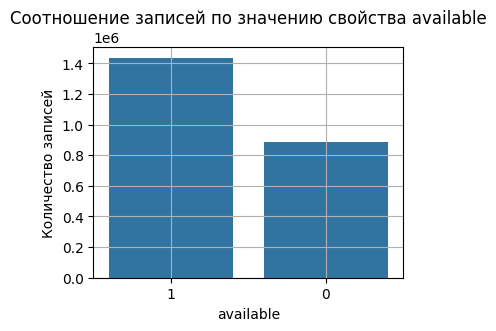

In [103]:
show_countplot(
    data=events_advanced_data,
    feature_name="available",
    title="Соотношение записей по значению свойства available",
    xlabel="available",
    ylabel="Количество записей",
    figsize=(4, 3),
)

Разница сравнимая, чаще `available` имеет значение `1`.\
Теперь посмотрим, как соотносится количество транзакций при `available = 1` и `available = 0`.

In [104]:
# Маска для фильтра транзакций 
mask_events_advanced_transaction = (events_advanced_data["event"] == "transaction")

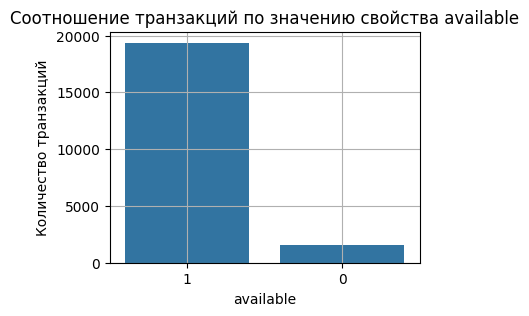

In [105]:
show_countplot(
    data=events_advanced_data[mask_events_advanced_transaction],
    feature_name="available",
    title="Соотношение транзакций по значению свойства available",
    xlabel="available",
    ylabel="Количество транзакций",
    figsize=(4, 3),
)

Видим, что при `available = 0` количество транзакций значительно меньше.\
И это соотношение не повторяет исходное соотношение записей со значениями `available`.\
Отсюда можно сделать вывод, что пользователи меньше покупают товары со свойством `available = 0`.\
Учтем это при рекомендациях товаров.

### Свойство `790` (вероятно, цена)

Добавим товарам значения свойства `property`, равное `790`.\
Как выше можно было заметить, его значения похожи на цену.

In [106]:
events_advanced_data = fill_property_values(events_advanced_data, "790")

In [107]:
# Переименуем столбец в price
events_advanced_data.rename(columns={"790": "price"}, inplace=True)

In [108]:
# Переведем значение в float величину из строки
def price_to_numeric(str_price: str) -> Optional[float]:
    if isinstance(str_price, str):
        # Убираем первую букву "n"
        return float(str_price[1:])
    return np.nan

events_advanced_data["price"] = events_advanced_data["price"].apply(price_to_numeric)

In [109]:
# Посмотрим на количество пропусков
print(
    "Доля пропусков в свойсте price составляет:", 
    round(events_advanced_data['price'].isna().mean()*100, 2),
    "%"
)

Доля пропусков в свойсте price составляет: 13.95 %


#### Распределение сумм транзакций

Посмотрим на распределение сумм транзакций.

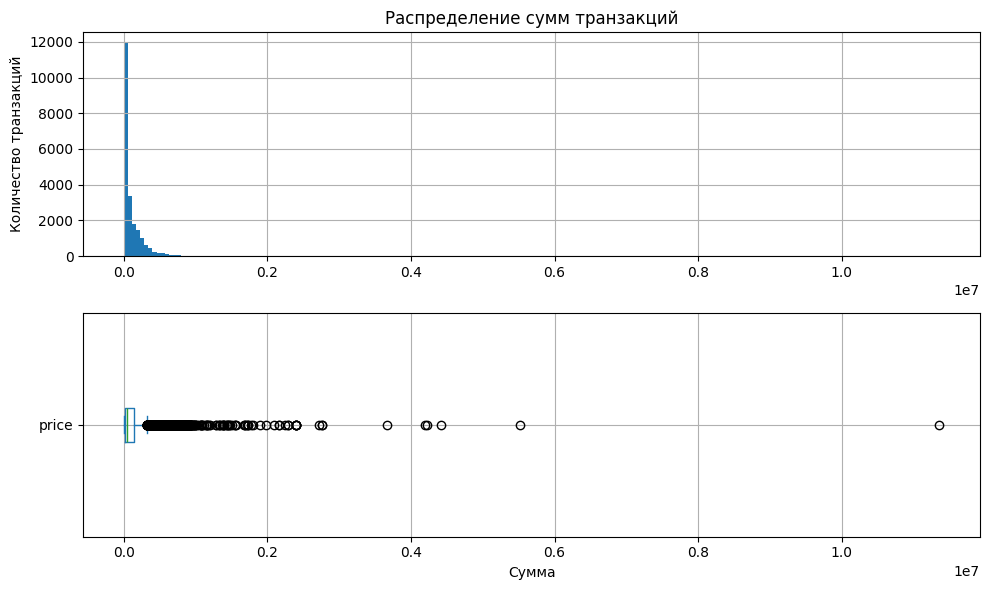

**Характеристики распределения:**

count    2.158500e+04
mean     1.082481e+05
std      1.859984e+05
min      0.000000e+00
25%      1.956000e+04
50%      4.728000e+04
75%      1.419360e+05
max      1.135908e+07
Name: price, dtype: float64

In [110]:
show_distribution_numeric_value(
    events_advanced_data[mask_events_advanced_transaction]["price"],
    title="Распределение сумм транзакций",
    xlabel="Сумма", 
    ylabel="Количество транзакций",
)

Посмотрим на распределение сумм, меньше миллиона.

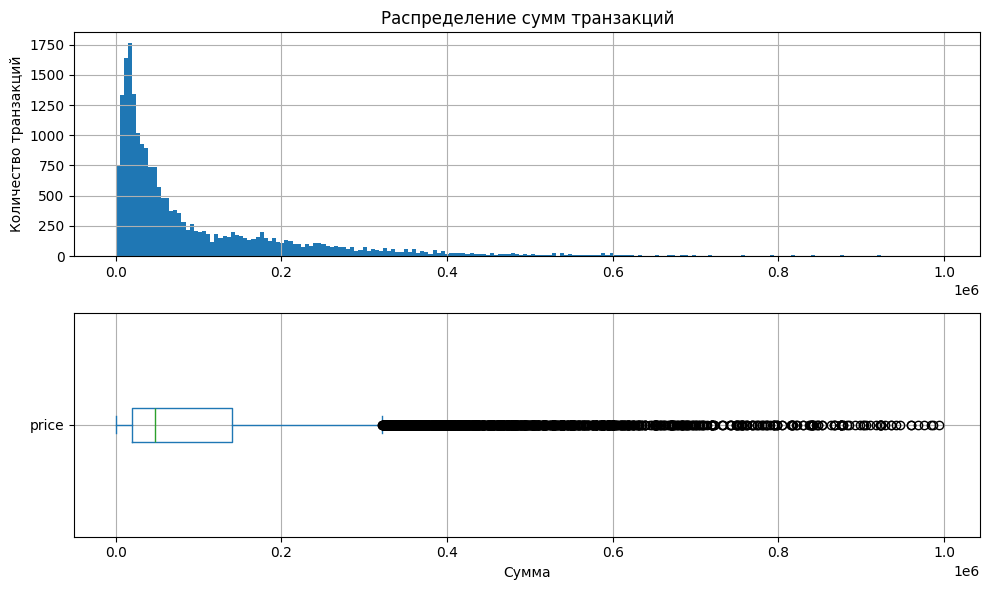

**Характеристики распределения:**

count     21520.000000
mean     102561.317286
std      131979.237924
min           0.000000
25%       19560.000000
50%       47040.000000
75%      140520.000000
max      993600.000000
Name: price, dtype: float64

In [111]:
mask_exclude_outline_price = (events_advanced_data["price"] < 1_000_000)

show_distribution_numeric_value(
    events_advanced_data[mask_events_advanced_transaction & mask_exclude_outline_price]["price"],
    title="Распределение сумм транзакций",
    xlabel="Сумма", 
    ylabel="Количество транзакций",
)

Распределение похоже на логнормальное.\
Пользователи чаще покупают товары подешевле.

И можно заметить транзакции с нулевой ценой.

#### Изучение товаров с нулевой ценой

Исследуем товары с нулевой ценой.\
Добавим для этого флаг `is_price_0`.

In [112]:
events_advanced_data["is_price_0"] = events_advanced_data["price"] == 0

Посмотрим на долю записей, в которых указана нулевая цена.

In [113]:
events_advanced_data["is_price_0"].value_counts(True)

is_price_0
False    0.997668
True     0.002332
Name: proportion, dtype: float64

Таких записей совсем немного.

Посмотрим на значение признака `available` у товаров с нулевой ценой.

In [114]:
mask_price_0 = events_advanced_data["is_price_0"] == True

events_advanced_data[mask_price_0]["available"].value_counts()

available
0    5803
Name: count, dtype: int64

У всех товаров с нулевой ценой значение доступности `available` также `0`.

### Свойство `categoryid` (категория)

Добавим также свойство с категорией товара.

In [115]:
events_advanced_data = fill_property_values(events_advanced_data, "categoryid")

In [120]:
# Посмотрим на количество пропусков
print(
    "Доля пропусков в свойсте categoryid составляет:", 
    round(events_advanced_data['categoryid'].isna().mean()*100, 2),
    "%"
)

Доля пропусков в свойсте categoryid составляет: 21.36 %


Добавим признак главной родительской категории.

In [124]:
categoryid_to_root = category_data.set_index("categoryid")["root_categoryid"].to_dict()

events_advanced_data["categoryid"] = events_advanced_data["categoryid"].astype(float)

def get_root_of_categoryid(categoryid: Optional[float]) -> Optional[float]:
    if not isinstance(categoryid, float) or not categoryid in categoryid_to_root:
        return None
    return categoryid_to_root[categoryid]

events_advanced_data["root_categoryid"] = \
    events_advanced_data["categoryid"].apply(get_root_of_categoryid)

In [125]:
# Посмотрим на количество пропусков
print(
    "Доля пропусков в свойсте root_categoryid составляет:", 
    round(events_advanced_data['root_categoryid'].isna().mean()*100, 2),
    "%"
)

Доля пропусков в свойсте root_categoryid составляет: 21.36 %


Посмотрим, товары какой категории чаще продавались.

In [126]:
events_advanced_data[mask_events_advanced_transaction] \
    ["root_categoryid"].value_counts(True).reset_index()

,root_categoryid,proportion
0,140.0,0.341749
1,1532.0,0.126654
2,1600.0,0.121127
3,1482.0,0.105023
4,395.0,0.072602
5,1224.0,0.067287
6,653.0,0.059474
7,679.0,0.027425
8,250.0,0.021844
9,1490.0,0.020888


Посмотрим на таблицу, которая получилась.

In [137]:
events_advanced_data.head(3)

,visitorid,event,itemid,transactionid,event_datetime,date,year,month,day,day_of_week,hour,minute,is_transaction,time_of_day,update_stage,available,price,is_price_0,categoryid,root_categoryid
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,2015,5,3,6,3,0,False,3-7,0,1,14280.0,False,NaN,NaN
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,2015,5,3,6,3,0,False,3-7,0,0,204120.0,False,NaN,NaN
2,652699,view,252860,NaN,2015-05-03 03:00:13.048,2015-05-03,2015,5,3,6,3,0,False,3-7,0,NaN,NaN,False,NaN,NaN


Сохраним ее для дальнейшего использования.

In [ ]:
# Если таблицу еще не сохраняли, то нужно вызвать эту строку
# events_advanced_data.to_csv(f"{DATA_PATH}/events_advanced_data.csv", index=False)

In [ ]:
# Если таблицу уже сохранили, то можно вызвать эту строку, 
# чтобы не повторять действия выше по созданию events_advanced_data
# events_advanced_data = pd.read_csv(f"{DATA_PATH}/events_advanced_data.csv")